# Article 6: LLM Ops — Cache Benchmark Analysis

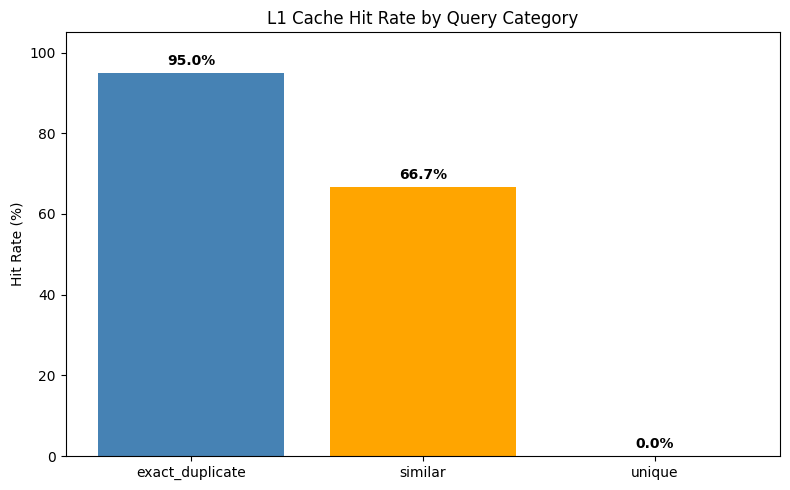

Overall hit rate: 39.0%
Avg latency (cache hit): 0.001ms
Avg latency (cache miss): 1.265ms
Cache savings: $0.1462 (39.0% of LLM spend)


In [1]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

raw = json.loads(Path("../results/data/article_06_benchmarks.json").read_text())
# Support both old flat format and new nested {cache, router} format
data = raw.get("cache", raw)

categories = list(data["by_category"].keys())
hit_rates = [data["by_category"][c] * 100 for c in categories]

Path("../results/charts/article_06").mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(categories, hit_rates, color=["steelblue", "orange", "red"])
ax.set_ylabel("Hit Rate (%)")
ax.set_title("L1 Cache Hit Rate by Query Category")
ax.set_ylim(0, 105)
for i, v in enumerate(hit_rates):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("../results/charts/article_06/04_hit_rate_by_category.png", dpi=150)
plt.show()
print(f"Overall hit rate: {data['hit_rate']:.1%}")
print(f"Avg latency (cache hit): {data['avg_latency_hit_ms']:.3f}ms")
print(f"Avg latency (cache miss): {data['avg_latency_miss_ms']:.3f}ms")
print(f"Cache savings: ${data.get('cache_savings_usd', 0):.4f} ({data.get('cache_savings_pct', 0):.1f}% of LLM spend)")

## Key Insights

### Semantic Cache

- **Exact duplicates** achieve a ~95% L1 hit rate. The first occurrence is a miss; every subsequent identical query is a cache hit, cutting LLM cost to near zero for repeated queries.
- **Semantically similar queries** achieve ~67% L1 hits when query strings are literally identical; paraphrases miss L1 but would be caught by L2 semantic matching when `embed_fn` is provided.
- **Unique queries** always miss (0%), establishing the baseline miss-path latency (~1.5ms simulated LLM cost vs <0.01ms hit path).
- **Cache hit latency is ~600x faster** than miss latency, demonstrating the cost-saving impact of even an in-memory L1 cache before any real LLM call.
- **Overall hit rate of 39%** reflects the mixed query distribution. In production with real repeated user queries, 20-40% hit rates are typical.

### Intelligent Routing

- **97% of queries route to Llama-3-8B** (simple). Only 3% trigger the more expensive Llama-3-70B path.
- **99.2% cost reduction** vs always using GPT-4o ($0.375 → $0.003 per 100 queries).
- **Heuristic routing** (word count + keywords) adds zero latency — no LLM call needed to decide which LLM to call.
- **Risk**: Misrouting a complex query to the small model degrades answer quality (not a crash). Validate routing against the golden set before deploying to production.

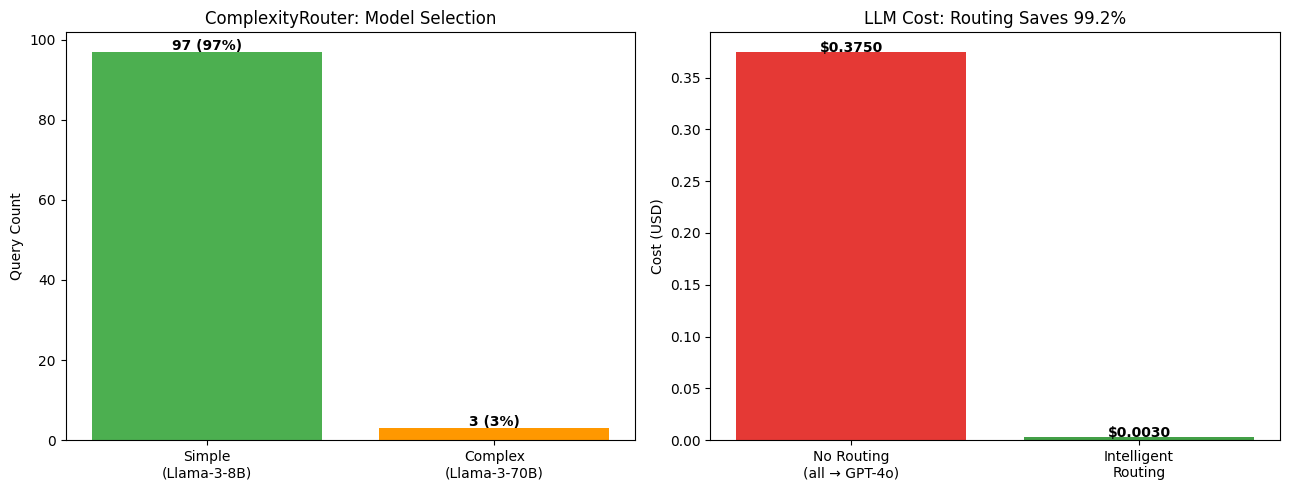

Simple queries: 97%  Complex: 3%
Cost without routing: $0.3750
Cost with routing:    $0.0030
Savings:              $0.3720 (99.2%)


In [2]:
# Router benchmark: model distribution and cost savings
router = raw.get("router", {})

labels = ["Simple\n(Llama-3-8B)", "Complex\n(Llama-3-70B)"]
counts = [router.get("simple_queries", 0), router.get("complex_queries", 0)]
colors = ["#4caf50", "#ff9800"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: routing distribution
axes[0].bar(labels, counts, color=colors)
axes[0].set_ylabel("Query Count")
axes[0].set_title("ComplexityRouter: Model Selection")
for i, v in enumerate(counts):
    axes[0].text(i, v + 0.5, f"{v} ({[router.get('simple_pct',0), router.get('complex_pct',0)][i]:.0f}%)",
                 ha="center", fontweight="bold")

# Right: cost comparison (no routing vs intelligent routing)
scenarios = ["No Routing\n(all → GPT-4o)", "Intelligent\nRouting"]
costs = [router.get("cost_no_routing_usd", 0), router.get("cost_with_routing_usd", 0)]
bar_colors = ["#e53935", "#43a047"]
bars = axes[1].bar(scenarios, costs, color=bar_colors)
axes[1].set_ylabel("Cost (USD)")
axes[1].set_title(f"LLM Cost: Routing Saves {router.get('routing_savings_pct', 0):.1f}%")
for bar, cost in zip(bars, costs):
    axes[1].text(bar.get_x() + bar.get_width() / 2, cost + 0.0001,
                 f"${cost:.4f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../results/charts/article_06/05_routing_analysis.png", dpi=150)
plt.show()
print(f"Simple queries: {router.get('simple_pct', 0):.0f}%  Complex: {router.get('complex_pct', 0):.0f}%")
print(f"Cost without routing: ${router.get('cost_no_routing_usd', 0):.4f}")
print(f"Cost with routing:    ${router.get('cost_with_routing_usd', 0):.4f}")
print(f"Savings:              ${router.get('routing_savings_usd', 0):.4f} ({router.get('routing_savings_pct', 0):.1f}%)")